<a href="https://colab.research.google.com/github/honeykgarg/PyTorch_NN/blob/regression_with_regularization/RegressionUsingNNLayersAndOptimizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt


In [2]:
x_train = np.array([[4.7], [2.4], [7.5], [7.1], [4.3],
                    [7.8], [8.9], [5.2], [4.59], [2.1],
                    [8], [5], [7.5], [5], [4],
                    [8], [5.2], [4.9], [3], [4.7],
                    [4], [4.8], [3.5], [2.1], [4.1]],
                   dtype = np.float32)

y_train = np.array([[2.6], [1.6], [3.09], [2.4], [2.4],
                    [3.3], [2.6], [1.96], [3.13], [1.76],
                    [3.2], [2.1], [1.6], [2.5], [2.2],
                    [2.75], [2.4], [1.8], [1], [2],
                    [1.6], [2.4], [2.6], [1.5], [3.1]],
                   dtype = np.float32)


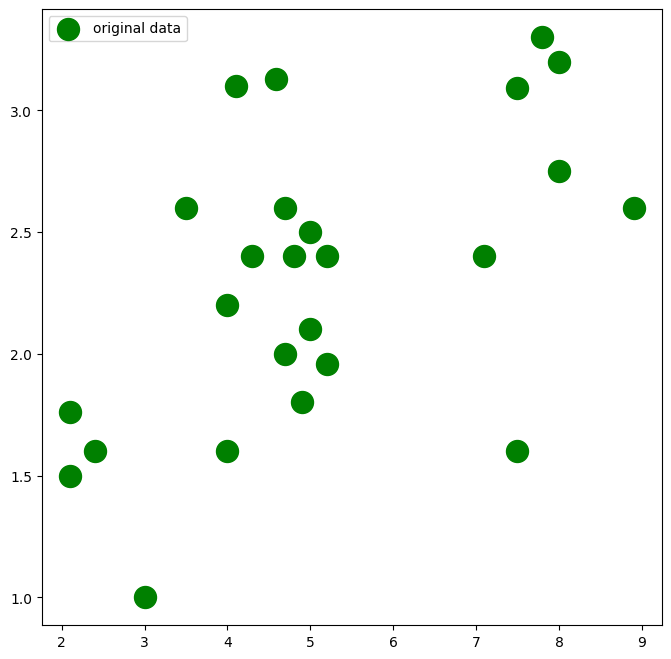

In [3]:
plt.figure(figsize=(8,8))
plt.scatter(x_train, y_train, label = 'original data', s=250, c='g')
plt.legend()
plt.show()

In [4]:
X_train = torch.from_numpy(x_train)
Y_train = torch.from_numpy(y_train)

In [5]:
X_train.size()

torch.Size([25, 1])

In [7]:
inp = 1
hidden = 5
out = 1

In [8]:
model = torch.nn.Sequential(torch.nn.Linear(inp, hidden),
                            torch.nn.ReLU(), torch.nn.Linear(hidden, out))

In [9]:
loss_function = torch.nn.MSELoss(reduction = 'sum')

In [12]:
learning_rate = 1e-4

for i in range(500):
  y_pred = model(X_train)

  loss = loss_function(y_pred, Y_train)
  print(i, loss.item())

  model.zero_grad()
  loss.backward()

  with torch.no_grad():
    for param in model.parameters():
      param -= learning_rate * param.grad



0 7.894078254699707
1 7.890418529510498
2 7.886763572692871
3 7.883114337921143
4 7.879472732543945
5 7.875837326049805
6 7.8722076416015625
7 7.868583679199219
8 7.864965915679932
9 7.861355304718018
10 7.8577494621276855
11 7.854150772094727
12 7.850555419921875
13 7.846968650817871
14 7.843387603759766
15 7.839811325073242
16 7.836241722106934
17 7.832677841186523
18 7.82912015914917
19 7.825568199157715
20 7.822022438049316
21 7.818481922149658
22 7.814948558807373
23 7.811420917510986
24 7.807899475097656
25 7.80438232421875
26 7.800872802734375
27 7.797369003295898
28 7.793869972229004
29 7.790377140045166
30 7.786890506744385
31 7.783409118652344
32 7.779934406280518
33 7.776464462280273
34 7.773001670837402
35 7.769545078277588
36 7.766092777252197
37 7.7626471519470215
38 7.759207248687744
39 7.755773544311523
40 7.752344131469727
41 7.748921871185303
42 7.745504379272461
43 7.742093086242676
44 7.738687515258789
45 7.735288143157959
46 7.7318949699401855
47 7.728506565093994


In [14]:
predicted_tensor = model(X_train)
predicted_tensor


tensor([[2.1524],
        [1.5764],
        [2.8536],
        [2.7534],
        [2.0522],
        [2.9287],
        [3.2042],
        [2.2776],
        [2.1249],
        [1.5013],
        [2.9788],
        [2.2275],
        [2.8536],
        [2.2275],
        [1.9771],
        [2.9788],
        [2.2776],
        [2.2025],
        [1.7267],
        [2.1524],
        [1.9771],
        [2.1774],
        [1.8519],
        [1.5013],
        [2.0021]], grad_fn=<AddmmBackward0>)

In [15]:
predicted = predicted_tensor.detach().numpy()

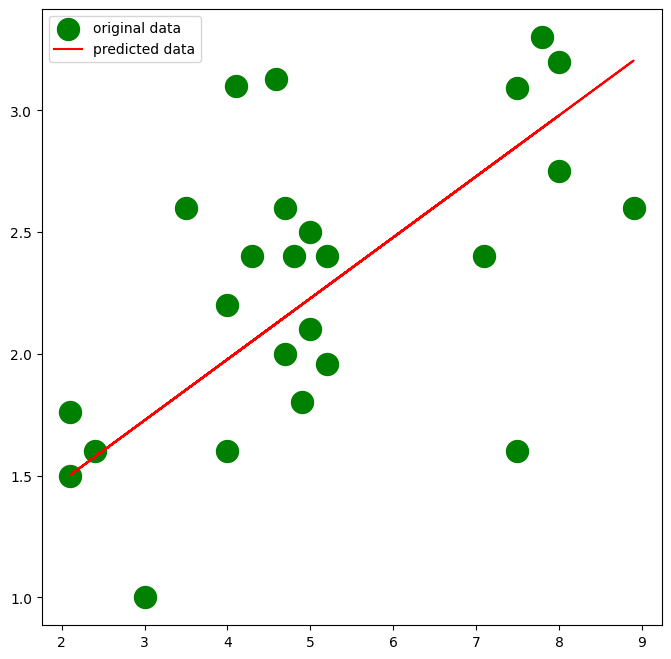

In [16]:
plt.figure(figsize=(8,8))
plt.scatter(x_train, y_train, label = 'original data', s=250, c='g')
plt.plot(x_train, predicted, label = 'predicted data', c='r')
plt.legend()
plt.show()